In [18]:
import os
import re
import time
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
from multiprocessing import Pool

In [19]:
# z Zadania 1
from datasets import load_dataset
import functools

@functools.lru_cache(maxsize=4)
def get_imdb_subset(split: str, n: int):
    ds = load_dataset("stanfordnlp/imdb", split=split).shuffle(seed=42).select(range(n))
    return [(r["text"], r["label"]) for r in ds]

In [20]:
POS_WORDS = {"good", "great", "excellent", "wonderful", "love", "best", "amazing", "brilliant", "perfect"}
NEG_WORDS = {"bad", "worst", "awful", "terrible", "hate", "boring", "waste", "poor", "horrible"}

In [21]:
def sentiment_score(text: str) -> int:
    words = re.findall(r"\w+", text.lower())

    positive = sum(1 for word in words if word in POS_WORDS)
    negative = sum(1 for word in words if word in NEG_WORDS)

    return positive - negative


samples = get_imdb_subset("train", 5000)
texts = [text for text, label in samples]

print(f"Liczba recenzji: {len(texts)}")

Liczba recenzji: 5000


In [22]:
#sekwencyjnie
start = time.time()
seq_results = [sentiment_score(text) for text in texts]
seq_time = time.time() - start

print(f"Sekwencyjnie: {seq_time:.3f}s")

Sekwencyjnie: 0.497s


In [23]:
# threadpool
start = time.time()

with ThreadPoolExecutor(max_workers=16) as pool:
    thread_results = list(pool.map(sentiment_score, texts))

thread_time = time.time() - start

print(f"ThreadPool: {thread_time:.3f}s")

ThreadPool: 0.864s


In [24]:
# multiprocessing
start = time.time()

with Pool(processes=os.cpu_count()) as pool:
    mp_results = pool.map(sentiment_score, texts, chunksize=100)

mp_time = time.time() - start

print(f"Multiprocessing: {mp_time:.3f}s")

Multiprocessing: 0.535s


In [25]:
# porownanie wynikow
print("Wyniki sekwencyjne == ThreadPool:", seq_results == thread_results)
print("Wyniki sekwencyjne == Multiprocessing:", seq_results == mp_results)

Wyniki sekwencyjne == ThreadPool: True
Wyniki sekwencyjne == Multiprocessing: True


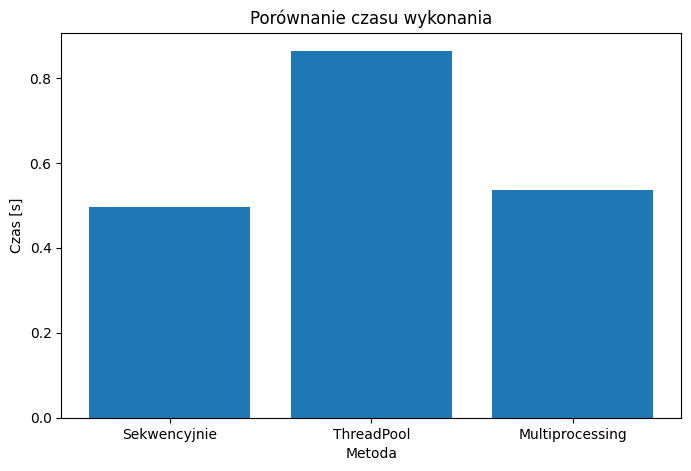

In [26]:
# wykres
methods = ["Sekwencyjnie", "ThreadPool", "Multiprocessing"]
times = [seq_time, thread_time, mp_time]

plt.figure(figsize=(8, 5))
plt.bar(methods, times)
plt.title("Porównanie czasu wykonania")
plt.ylabel("Czas [s]")
plt.xlabel("Metoda")
plt.show()

In [27]:
best_method = methods[times.index(min(times))]

print(f"Najszybsza metoda w tym uruchomieniu: {best_method}.")

Najszybsza metoda w tym uruchomieniu: Sekwencyjnie.


### Wniosek

W przeprowadzonym eksperymencie na 5000 recenzjach najszybsze okazało się wykonanie sekwencyjne, które zajęło 0.497 s. Multiprocessing osiągnął bardzo zbliżony wynik (0.535 s), natomiast ThreadPool był wyraźnie wolniejszy (0.864 s).

Otrzymany rezultat różni się od oczekiwań teoretycznych. Chociaż multiprocessing pozwala ominąć ograniczenie GIL i zwykle sprawdza się lepiej przy zadaniach CPU-bound, w tym przypadku samo obliczenie sentymentu było stosunkowo proste i krótkie. Narzut związany z tworzeniem procesów oraz przekazywaniem danych między nimi okazał się porównywalny z czasem samych obliczeń, dlatego nie udało się uzyskać zauważalnego przyspieszenia.

Wyniki wszystkich trzech metod były identyczne, co potwierdza poprawność implementacji. Eksperyment pokazuje, że wykorzystanie współbieżności nie zawsze gwarantuje lepszą wydajność — korzyści pojawiają się głównie przy bardziej złożonych i czasochłonnych obliczeniach.